OVERVIEW: Observe the transit of a well-studied exoplanet. Include significant pre- and post-transit observations to simulate a nominal Pandora transit observation. (Ideally ~ 24 hours of observing centered on the transit.) 
    

DATA PRODUCT: 
    This data will demonstrate that the mission can successfully plan, execute, and analyze exoplanet transit photometry and spectroscopy. 
    Additionally, observing a known-flat spectra will provide an opportunity to identify potential instrument systematics early in the mission.

    
EXIT CRITERIA: observations obtained, analysis complete and summarized in 3.99_ResultsSummary.md
- Photometry and spectroscopy of the exoplanet transit and a substantial baseline are obtained with TBD VIS S/N and TBD NIR S/N.
    
    
DATA VOLUME:
    
    
TARGET CRITERIA: The chosen exoplanet should be known to have a featureless atmosphere.
    
    
KEY STAKEHOLDERS: Tom Greene

## Load In

In [1]:
''' Make sure you have pandorasim installed and updated '''
# pandorasim, Version: 1.0.10
# pandorasat, Version: 0.5.22

import pandorasat as ps
import pandorasim as pp
ps.utils.get_phoenix_model(teff=7000, jmag=10) ### this is a temporary fix to an import error with pandorasim
from pandorasim import VisibleSim, NIRSim
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, Longitude
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta
import matplotlib.patches as patches

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan 
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, regions_NIR, bits_per_pix_NIR, compression_fractor_NIR, NIR_ra_shape, NIR_dec_shape, VIS_ra_shape, VIS_dec_shape


/Users/lindseywiser/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Data Volume

1 observation, simultaneous NIR and VIS. Observation setup is the standard setup for science observation
- VIS: 9 50x50 subarrays
- NIR: 1 84x400 subarray

In [3]:
##### VIS Observations #####
frames_per_int_VIS      = 50
regions_VIS             = 9
VIS_xpix                = 50
VIS_ypix                = 50
num_int_VIS             = 9000
bits_per_int_VIS        = VIS_xpix * VIS_ypix * regions_VIS * bits_per_pix_VIS * stored_frames_per_int_VIS
int_and_reset_time_VIS  = frame_time_VIS * frames_per_int_VIS
bits_per_sec_VIS        = bits_per_int_VIS / int_and_reset_time_VIS
bits_per_sec_comp_VIS   = bits_per_sec_VIS / compression_fractor_VIS
test_time_VIS           = num_int_VIS * int_and_reset_time_VIS
bits_test_total_VIS     = bits_per_sec_comp_VIS * test_time_VIS
Gbits_test_packet_VIS   = bits_test_total_VIS / 1E9 * 1.1 * 1.25
downlinks_VIS           = Gbits_test_packet_VIS * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observations:', Gbits_test_packet_VIS, 'Gbits')


VIS Observations: 2.9700000000000006 Gbits


In [4]:
##### NIR Observations #####
NIR_xpix                   = 84
NIR_ypix                   = 400
frames_per_int_NIR         = 24
stored_frames_per_int_NIR  = 2
num_int_NIR                = 10715
frame_time_NIR             = NIR_xpix * NIR_ypix * 0.00001 #sec 
int_and_reset_time_NIR     = frame_time_NIR * (frames_per_int_NIR+1)
bits_per_int_NIR           = NIR_xpix * NIR_ypix * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR
bits_per_sec_NIR           = bits_per_int_NIR / int_and_reset_time_NIR
test_time_NIR              = num_int_NIR * int_and_reset_time_NIR
bits_per_sec_comp_NIR      = bits_per_sec_NIR / compression_fractor_NIR
bits_test_total_NIR        = bits_per_sec_comp_NIR * test_time_NIR
Gbits_test_packet_NIR      = bits_test_total_NIR / 1E9 * 1.1 * 1.25
downlinks_NIR              = Gbits_test_packet_NIR * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations:', Gbits_test_packet_NIR, 'Gbits')


NIR Observations: 7.920528000000001 Gbits


In [5]:
Gbits_total = Gbits_test_packet_VIS + Gbits_test_packet_NIR
downlinks_total = downlinks_VIS + downlinks_NIR
test_time_total = np.max([test_time_VIS, test_time_NIR])

print('Test time, total, no slew/overhead time:', test_time_total/60/60, 'hours')
print('Volume, total:', Gbits_total, 'Gbits')
print('Downlinks, total:', downlinks_total)

Test time, total, no slew/overhead time: 25.001666666666665 hours
Volume, total: 10.890528000000002 Gbits
Downlinks, total: 4.53772


## Define Target

In [6]:
### Possible Targets:
# ...
# ...
# ...
# ...
# ...

In [7]:
''' Finds target coordinates based on astropy '''
### You can do this differently as long as you have DEC and RA
target = "GJ 3470"
c = SkyCoord.from_name(target)


''' Identify the start time and end time of the observation '''
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(test_time_VIS, test_time_NIR)
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta


''' Initialize a simulator object '''
### Set the number of ROIs and their sizes. 
### For now, NIRSim does not allow you to set the ROI_size. But we can still set it in the SOC file at the end.
simVIS = VisibleSim(ROI_size=(VIS_xpix, VIS_ypix), nROIs=regions_VIS) 
simNIR = NIRSim() # NIRSim(ROI_size=(obs_dict[nir]['xpix'], obs_dict[nir]['ypix']))

''' Point the simulator to the corrected location '''
###        RA,   DEC,    Theta 
theta0     = 0*u.deg
simVIS.point(c.ra, c.dec, theta0)
simNIR.point(c.ra, c.dec, theta0)

Output()

Output()

Output()

Output()

Output()

Output()

Output()

2025-03-04 14:37:44 WARNING: 0.0K source in catalog is not modelable. Setting to 2000K.

Output()

## Generate Observation

### VIS Observation

<Axes: title={'center': 'VISDA\n(RA:119.77 deg, Dec:15.39 deg, Roll:0.00 deg)'}, xlabel='Column [pixel]', ylabel='Row [pixel]'>

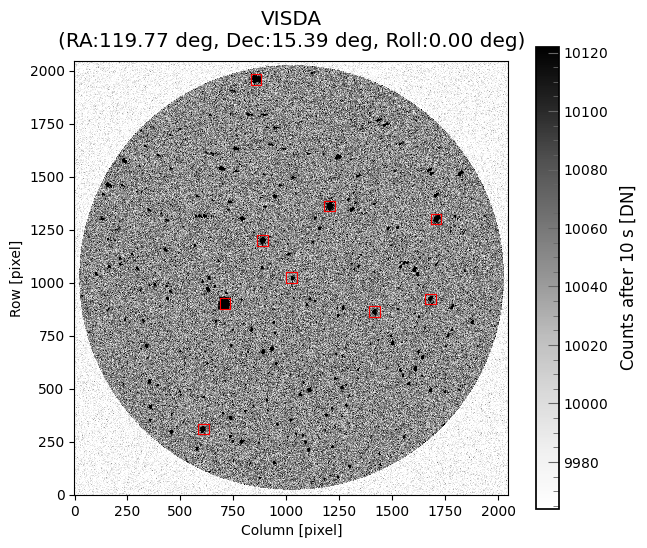

In [8]:
''' Plot the VIS Full Frame Image. ROIs are in red boxes defining the subarrays. '''
simVIS.show_FFI()

In [9]:
''' Create an Observation. '''
### This returns an astropy.io.fits.HDUList array. 
# `nreads` sets how many reads of the detector are coadded together to create a frame.
# `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
# `nframes` sets how many frames will be returned.
# `start_time` indicates the time of observation. 
# `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 
###

### reduce the number of integrations to speed up calculations
reduction = 100 # set to 1 for no reduction
data = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(num_int_VIS/reduction), start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|█████████████████| 22/22 [00:03<00:00,  6.49it/s]


(9, 90, 50, 50)

### NIR Observation

In [ ]:
''' Plot the NIRDA subarray '''
simNIR.show_subarray();

In [ ]:
''' Create a NIRDA observation. '''
### This returns an astropy.io.fits.HDUList array. The following parameters can be adjusted
# SC_Resets1 : Number of reset frames at the start of the first integration of exposure
# SC_Resets2 : Number of resent frames at the start of 1 through n integrations of exposure
# SC_DropFrames1 : Number of dropped frames after reset of any integration of exposure
# SC_DropFrames2 : Number of dropped frames in every group of integrations of exposure except the last group
# SC_DropFrames3 : Number of dropped frames in the last group of each integration of exposure
# SC_ReadFrames : Number of frames read during each group of integration of exposure
# SC_Groups : Number of groups per integration of exposure
# SC_Integrations : Number of integrations per exposure
# start_time : Time to start the observation. This is only used if returning a fits file, or supplying a flux function.
# noise : bool flag determining whether noise is simulated and included. Default is True.
# jitter : bool flag determining whether jitter is simulated and included. Default is True.
# output_type : String flag to determine the result output. Valid strings are "fits" or "array
###

ROIsize_override = (NIR_xpix, NIR_ypix) ### THIS CANNOT YET BE SPECIFIED IN sim.observe()

data = simNIR.observe(SC_Integrations=num_int_NIR, SC_ReadFrames=stored_frames_per_int_NIR, start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

## Save the Simulated Observation

In [ ]:
''' Re-Create the observations in the correct format for the .fits file (i.e., output_type set to default) '''
### Before, object_type was array for easy computation in this notebook, but that is not correct for the .fits file
hdulist_vis = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(num_int_VIS/reduction), start_time=start_time)
hdulist_nir = simNIR.observe(SC_Integrations=num_int_NIR, SC_ReadFrames=stored_frames_per_int_NIR, start_time=start_time)


''' Save our simulated observation in a fits file '''
targ = target.replace(" ", "")
VISrois_outfile = "3.60_VISrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
NIRrois_outfile = "3.60_NIRrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
hdulist_vis.writeto(VISrois_outfile, overwrite=True)
hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

In [ ]:
### Show what is in our fits file: 
'''
Three FITS file extensions: 
    (1) PRIMARY: information about the simulated observation 
    (2) SCIENCE: data info, images
    (3) ROITABLE: VISDA pixel coordinates of the origin of the subarray, which is defined as the lower left corner
'''

hdul_rois = fits.open(VISrois_outfile) ### or NIRrois_outfile
print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_rois[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_rois[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROITABLE Headers --')
#print(hdul_rois[2].header)

## Data Products

### Demonstrate that the mission can successfully plan, execute, and analyze exoplanet transit photometry and spectroscopy. 

### Observing a known-flat spectra will provide an opportunity to identify potential instrument systematics early in the mission.

## Generate SOC File

In [ ]:
'Here we define the information required for scheduling the observation.'''
### Some variables may be removed/added/changed. Working on defining these with SOC meetings. 
### This is not all correct! Revisit and check once notebook is complete. 

variables = {
    'visit_id': '0399', ### setting based on task number. Could change. 
    'obs_id': f"{observation_number:03}", ### setting based on observation number. 
    'target': target, 
    'priority': 1, ### all commissioning is priority 1
    'start_time': start_time, 
    'stop_time': end_time, 
    'RA': ra0,
    'DEC': dec0, 
    
    'NIR_AvgGroups': 2, ### check what this is
    'NIR_ROI_StartX': ra0, 
    'NIR_ROI_StartY': dec0, 
    'NIR_ROI_SizeX': NIR_xpix, 
    'NIR_ROI_SizeY': NIR_ypix,
    'NIR_SC_Resets1': 1,
    'NIR_SC_Resets2': 1, 
    'NIR_SC_DropFrames1': 0,
    'NIR_SC_DropFrames2': 16,
    'NIR_SC_DropFrames3': 0, 
    'NIR_SC_ReadFrames': frames_per_int_NIR,
    'NIR_targetID': target, 
    'NIR_SC_Groups': 2,
    'NIR_SC_Integrations': obs_dict[nir]['num_int'], 
    
    'VIS_StarRoiDetMethod': 0,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': frames_per_int_VIS, 
    'VIS_NumTotalFramesRequested': obs_dict[vis]['num_int'], 
    'VIS_TargetRA': ra0, 
    'VIS_TargetDEC': dec0, 
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [VIS_xpix, VIS_ypix], 
    'VIS_MaxNumStarRois': '', ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': regions_VIS, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': '', ### currently defining as corner of ROI. We may update this to be ROI centers.
    'VIS_PredefinedStarRoiDec': '', 
    'VIS_targetID': target, 
    'VIS_NumExposuresMax': obs_dict[vis]['num_int'], 
    'VIS_ExposureTime_us': frame_time_VIS * 1000000  
}

In [ ]:
'''Generate the SOC .xml file'''

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_example_SOC.xml' 
generate_task_plan(variables, output_soc_file)

## STOP HERE. The following cells are testing 

In [4]:
##### Import Stellar Spectrum #####

### Expecting a PHOENIX model.

### import via pandora-sim & gaia
target = ps.Target.from_gaia("GJ 436")
wave = np.arange(0.1, 2, 0.001) * u.micron
star_spec = target.spectrum(wave) 

### import via direct PHOENIX model (code copied from elsewhere and not set up to work here yet)
'''
lambdastar_hi, Fstar0=np.loadtxt('PHOENIX_3416_4.83.txt').T 

#smooth star
szmod=len(wno)
Fstar_smooth=np.zeros(szmod)
dwno=wno[1:]-wno[:-1]
for i in range(szmod-1):
    i=i+1
    loc=np.where((1E4/lambdastar_hi >= wno[i]-0.5*dwno[i-1]) & (1E4/lambdastar_hi < wno[i]+0.5*dwno[i-1]))
    Fstar_smooth[i]=np.mean(Fstar0[loc])

Fstar_smooth[0]=Fstar_smooth[1]
Fstar_smooth[-1]=Fstar_smooth[-2]
Fstar=Fstar_smooth
FF= Fstar[wno <= 1820.][-1]
wl_FF=1E4/wno[wno <= 1820][-1]
TB=Brightness_Temp(FF, wl_FF*1E-6)
BBStar=np.pi*blackbody(TB,1E4/wno*1E-6)
Fstar[wno <= 1820.]=BBStar[wno <= 1820]
#Fstar[np.isnan(Fstar)]=1E50
#Fstar[wno <= 1800]=1E50
'''

#print(wave)
#print(star_spec)
#print(float(target.planets['b']['pl_trandep'])) #this gives info about the planet GJ 436 b

"\nlambdastar_hi, Fstar0=np.loadtxt('PHOENIX_3416_4.83.txt').T \n\n#smooth star\nszmod=len(wno)\nFstar_smooth=np.zeros(szmod)\ndwno=wno[1:]-wno[:-1]\nfor i in range(szmod-1):\n    i=i+1\n    loc=np.where((1E4/lambdastar_hi >= wno[i]-0.5*dwno[i-1]) & (1E4/lambdastar_hi < wno[i]+0.5*dwno[i-1]))\n    Fstar_smooth[i]=np.mean(Fstar0[loc])\n\nFstar_smooth[0]=Fstar_smooth[1]\nFstar_smooth[-1]=Fstar_smooth[-2]\nFstar=Fstar_smooth\nFF= Fstar[wno <= 1820.][-1]\nwl_FF=1E4/wno[wno <= 1820][-1]\nTB=Brightness_Temp(FF, wl_FF*1E-6)\nBBStar=np.pi*blackbody(TB,1E4/wno*1E-6)\nFstar[wno <= 1820.]=BBStar[wno <= 1820]\n#Fstar[np.isnan(Fstar)]=1E50\n#Fstar[wno <= 1800]=1E50\n"

In [6]:
##### Import Transit Model #####

### Expecting spectrum in transit depth fraction (i.e., 1% dip = 0.01). 
### If importing a model with different units, update that here.

### flat spectrum
#trans_dep = np.full((len(wave),),0.01) # flat spectrum

### random spectrum, based on typical depth of planet in the system
low_dep = (float(target.planets['b']['pl_trandep']) - 0.002)
high_dep = (float(target.planets['b']['pl_trandep']) + 0.002)
trans_dep = np.random.uniform(low=low_dep, high=high_dep, size=(len(wave),)) 

### real spectrum -- expecting ScCHIMERA
### for other spectra, may need to interpolate points to line up with stellar spectrum

#print(len(wave))
#print(trans_dep)

Text(0, 0.5, 'transit depth (fraction)')

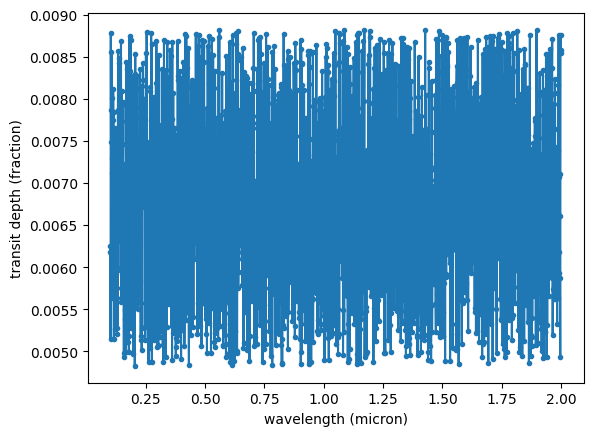

In [7]:
##### Plot Transit Spectrum - transit depth (fraction) vs. wavelength (micron) ###

plt.plot(wave, trans_dep, '.-')
plt.xlabel("wavelength (micron)")
plt.ylabel("transit depth (fraction)")
#plt.xlim(0.8, 1.6)
#plt.ylim(0.58, 0.62)

# Simple Pandora Sim Light Curve

Text(0, 0.5, 'relative flux (fraction)')

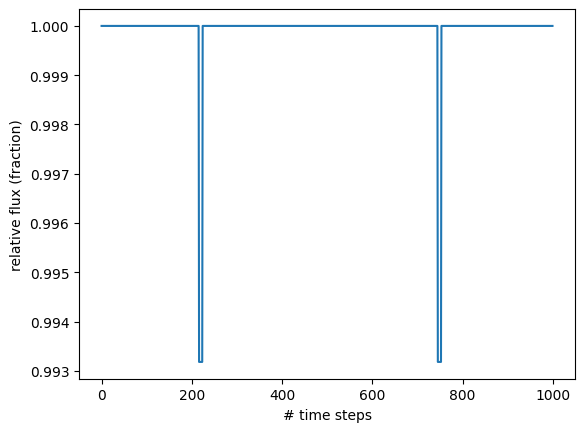

In [8]:
### this light curve doesn't include variation with wavelength, and only a box transit for now

transit = target.box_transit(time=np.arange(0, 5, 0.005)) 

plt.plot(transit)
plt.xlabel("# time steps")
plt.ylabel("relative flux (fraction)")

# Build Batman Lightcurves

In [9]:
##### Initialize Batman model ###

# The initialization step calculates the separation of centers between the star and the planet, 
# as well as the integration step size (for “square-root”, “logarithmic”, “exponential”, “nonlinear”, 
# “power2”, and “custom” limb darkening).

params = batman.TransitParams()       #object to store transit parameters
params.t0 = 0.                        #time of inferior conjunction
params.per = 2.64389759               #orbital period (days?)
rp_jup = 0.366                        #planet radius (in units of jupiter radii)
rs_sun = 0.455                        #star radius (in units of solar radii)
params.rp = (rp_jup/9.731)/rs_sun     #planet radius (in units of stellar radii)
sa_AU = 0.0308                        #semi-major axis (in units of AU)
params.a = sa_AU/(rs_sun/215.)        #semi-major axis (in units of stellar radii)
params.inc = 85.8                     #orbital inclination (in degrees)
params.ecc = 0.1616                   #eccentricity
params.w = 90.                        #longitude of periastron (in degrees)  # COME BACK TO THIS
params.limb_dark = "nonlinear"        #limb darkening model
params.u = [0.5, 0.1, 0.1, -0.1]      #limb darkening coefficients [u1, u2, u3, u4]

t = np.linspace(-0.025, 0.025, 1000)  #times at which to calculate light curve
m = batman.TransitModel(params, t)    #initializes model

Text(0, 0.5, 'relative flux (fraction)')

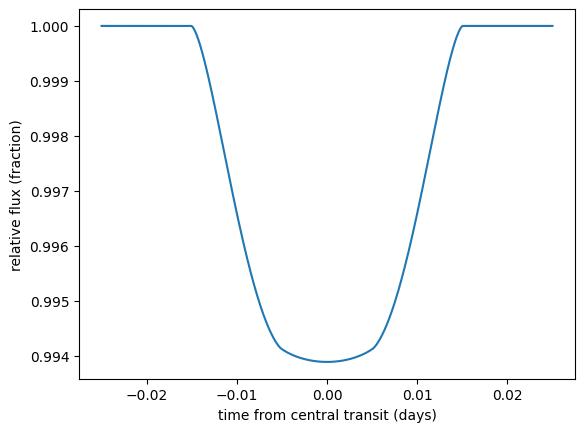

In [10]:
### calculates one light curve
flux = m.light_curve(params) 

plt.plot(t, flux)
plt.xlabel("time from central transit (days)")
plt.ylabel("relative flux (fraction)")

1900


Text(0, 0.5, 'relative flux (fraction)')

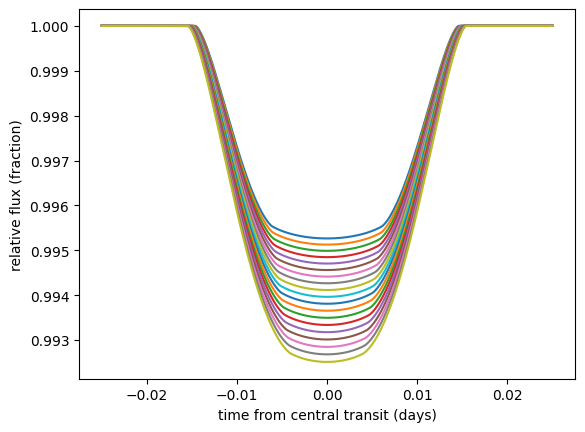

In [11]:
##### Calculating wavelength dependant light curves #####
### Here, we need to make light curves for different wavelengths, i.e. different planet radii 

### First, calculate planet radii at each wavelength from the transit spectrum model
radii = np.linspace(params.rp-0.01, params.rp+0.01, len(wave)) #random numbers for now. Need to calc from trans_dep

print(len(radii))
### Second, calculate light curve at each wavelength
### save these light curves in 2D array -- wavelength on x (num of columns), time on y (num of rows)
lightcurves_2d = np.zeros((len(t), len(wave)))

for i in range(len(radii)):
    r = radii[i]
    params.rp = r                           #updates planet radius
    new_flux = m.light_curve(params)        #recalculates light curve

    lightcurves_2d[:, i] = new_flux

    if i%100==0:
        plt.plot(t, new_flux)

plt.xlabel("time from central transit (days)")
plt.ylabel("relative flux (fraction)")

# Add Transit to Stellar Spectrum

In [12]:
##### SIMPLE OUTPUT: spectrum at center of transit #####
### this ignores the shape of light curves and just subtracts the transit spectrum from the stellar one
### do I need to consider emission from planet in out-of-transit spec?

tran_spec = np.multiply(star_spec, 1-trans_dep)

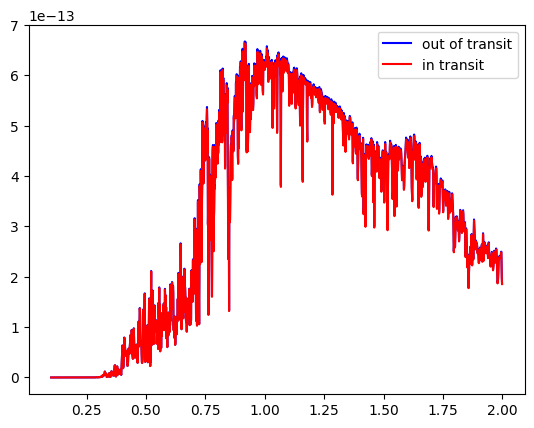

In [13]:
##### Plot the new spectrum ####
plt.plot(wave, star_spec, color='blue', label='out of transit')
plt.plot(wave, tran_spec, color='red', label='in transit')
plt.legend()

In [18]:
##### COMPLEX OUTPUT: Calculate time-dependant spectrum as transit occurs ####

star_spec_overtime = np.tile(star_spec, (len(t), 1)) #creates a 2D array matching lightcurves_2d with the stellar spec on every row
time_dependant_spec = np.zeros((len(t), len(wave)))

for i in range(len(t)): #loop through each time and find the stellar spectrum
    #print(star_spec_overtime[i,:])
    newarray=[]
    for j in range(len(wave)):
        val = star_spec_overtime[i,j].value - (star_spec_overtime[i,j].value * (1-lightcurves_2d[i,j]))
        #print(val)
        newarray = np.append(newarray, val)
        #print(newarray)
    
    time_dependant_spec[i,:] = newarray

In [36]:
#print(time_dependant_spec.shape)
#print(time_dependant_spec)

(5e-13, 6.5e-13)

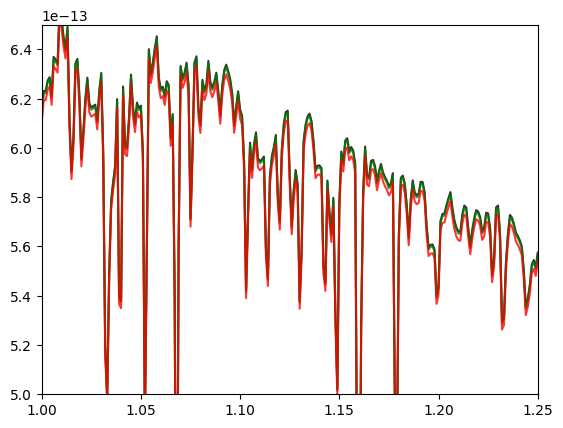

In [37]:
### plotting the stellar spectrum at different points throughout the planet's transit ###

# define times to plot
t1 = 0
t2 = 250
t3 = 500   #500 is the transit center. 1000 time steps total.

plt.plot(wave, time_dependant_spec[t1,:], color='black', alpha=0.8)
plt.plot(wave, time_dependant_spec[t2,:], color='green', alpha=0.8)
plt.plot(wave, time_dependant_spec[t3,:], color='red', alpha=0.8)

# zooming in to see the variation
plt.xlim(1., 1.25)
plt.ylim(5.e-13, 6.5e-13)